# 07 - Explainable AI and Recovery Strategy Engine

## Explainability definition
SHAP quantifies how each feature contributes to a prediction for both global and local explanations.

## Business purpose
Collections teams need transparent reasons behind risk scores before acting.


## Definition
Explainability and strategy logic connect model outputs to actionable, auditable recovery decisions.

## Theory
This section explains the statistical or ML theory behind the technique and why it is useful in credit recovery operations.

## Mathematical Intuition
We translate the idea into score/probability/ranking logic so each metric can be interpreted quantitatively.

## Financial Intuition
We connect the method to borrower affordability, delinquency severity, collateral protection, and expected recoverable cashflows.

## Business Impact
We explain what this enables for collection managers, risk teams, and executives.

## Real-World Example
If risk is very high and collateral is weak, the strategy escalates from reminders to legal pathway preparation.

## Visual Explanation
Charts in this notebook show how model/segment behavior changes across borrower groups.

## Code Explanation
Every code cell below is paired with interpretation so beginners can connect implementation details to business outcomes.

## Interpretation of Results
We summarize what changed, why it matters, and how to act on it.


In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.loan_recovery import (
    DATA_PATH,
    FIGURES_DIR,
    MODELS_DIR,
    TABLES_DIR,
    REPORTS_DIR,
    LoanDataLoader,
    FeatureEngineer,
    LoanEDA,
    BorrowerSegmenter,
    ModelTrainer,
    ModelEvaluator,
    RecoveryStrategyEngine,
    ModelExplainer,
    DashboardBuilder,
    LazyPredictBenchmark,
    PyCaretWorkflow,
    FLAMLOptimizer,
    SmartLoanRecoveryPipeline,
    load_model,
)

sns.set_theme(style="whitegrid")


In [2]:
def ensure_pipeline_artifacts() -> None:
    required = [
        TABLES_DIR / "manual_model_leaderboard.csv",
        TABLES_DIR / "feature_enriched_data.csv",
        MODELS_DIR / "best_manual_model.joblib",
    ]
    if not all(path.exists() for path in required):
        pipeline = SmartLoanRecoveryPipeline(data_path=DATA_PATH, random_state=42)
        pipeline.run()

ensure_pipeline_artifacts()


In [3]:
enriched = pd.read_csv(TABLES_DIR / "feature_enriched_data.csv")
model = load_model(MODELS_DIR / "best_manual_model.joblib")

strategy = RecoveryStrategyEngine(model=model, feature_engineer=FeatureEngineer())
scored = strategy.score_portfolio(enriched)
assigned = strategy.assign_strategies(scored)
scenario_df = strategy.what_if_scenarios(enriched)

display(assigned[["Borrower_ID", "risk_score", "risk_tier", "recommended_strategy", "priority_rank"]].head(20))
display(scenario_df)


,Borrower_ID,risk_score,risk_tier,recommended_strategy,priority_rank
0,BOR0000,0.564433,Very High,Legal notice preparation and debt recovery esc...,1
124,BOR0124,0.563839,Very High,Legal notice preparation and debt recovery esc...,2
471,BOR0471,0.549681,Very High,Legal notice preparation and debt recovery esc...,3
129,BOR0129,0.532171,High,Intensive collections with senior agent interv...,4
459,BOR0459,0.595504,Very High,Legal notice preparation and debt recovery esc...,5
202,BOR0202,0.547739,Very High,Legal notice preparation and debt recovery esc...,6
98,BOR0098,0.559686,Very High,Legal notice preparation and debt recovery esc...,7
415,BOR0415,0.564694,Very High,Legal notice preparation and debt recovery esc...,8
37,BOR0037,0.558878,Very High,Legal notice preparation and debt recovery esc...,9
297,BOR0297,0.534794,High,Intensive collections with senior agent interv...,10


,scenario,avg_risk_score,avg_recovery_probability,expected_recovery_value
0,Baseline,0.4549,0.6578,6697887.73
1,Income +20%,0.4533,0.6603,6722994.42
2,EMI -15% (Rate Relief),0.4538,0.6595,6715154.95
3,Missed payments +3,0.4821,0.6576,6695804.58
4,Collateral -20%,0.4559,0.6563,6689765.66


In [4]:
split = FeatureEngineer().train_test_split(enriched, target_col="Recovery_Status", drop_cols=["Borrower_ID"])
explainer = ModelExplainer(model)
shap_out = explainer.explain(split.x_test)
shap_out


/home/ahmad/AI/Github/40 AI-ML Projects for Beginners/Core Machine Learning and Data Science/Smart Loan Recovery System/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


/home/ahmad/AI/Github/40 AI-ML Projects for Beginners/Core Machine Learning and Data Science/Smart Loan Recovery System/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
/home/ahmad/AI/Github/40 AI-ML Projects for Beginners/Core Machine Learning and Data Science/Smart Loan Recovery System/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
/home/ahmad/AI/Github/40 AI-ML Projects for Beginners/Core Machine Learning and Data Science/Smart Loan Recovery System/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
/home/ahmad/AI/Github/40 AI-ML Projects for Beginners/Core Machine Learning and Data Science/Smart Loan Recovery System/.venv/lib/python3.12/site-packages/sk

/home/ahmad/AI/Github/40 AI-ML Projects for Beginners/Core Machine Learning and Data Science/Smart Loan Recovery System/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
/home/ahmad/AI/Github/40 AI-ML Projects for Beginners/Core Machine Learning and Data Science/Smart Loan Recovery System/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
/home/ahmad/AI/Github/40 AI-ML Projects for Beginners/Core Machine Learning and Data Science/Smart Loan Recovery System/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
/home/ahmad/AI/Github/40 AI-ML Projects for Beginners/Core Machine Learning and Data Science/Smart Loan Recovery System/.venv/lib/python3.12/site-packages/sk

/home/ahmad/AI/Github/40 AI-ML Projects for Beginners/Core Machine Learning and Data Science/Smart Loan Recovery System/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
/home/ahmad/AI/Github/40 AI-ML Projects for Beginners/Core Machine Learning and Data Science/Smart Loan Recovery System/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
/home/ahmad/AI/Github/40 AI-ML Projects for Beginners/Core Machine Learning and Data Science/Smart Loan Recovery System/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
/home/ahmad/AI/Github/40 AI-ML Projects for Beginners/Core Machine Learning and Data Science/Smart Loan Recovery System/.venv/lib/python3.12/site-packages/sk

/home/ahmad/AI/Github/40 AI-ML Projects for Beginners/Core Machine Learning and Data Science/Smart Loan Recovery System/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
/home/ahmad/AI/Github/40 AI-ML Projects for Beginners/Core Machine Learning and Data Science/Smart Loan Recovery System/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
/home/ahmad/AI/Github/40 AI-ML Projects for Beginners/Core Machine Learning and Data Science/Smart Loan Recovery System/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
/home/ahmad/AI/Github/40 AI-ML Projects for Beginners/Core Machine Learning and Data Science/Smart Loan Recovery System/.venv/lib/python3.12/site-packages/sk

...

/home/ahmad/AI/Github/40 AI-ML Projects for Beginners/Core Machine Learning and Data Science/Smart Loan Recovery System/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
/home/ahmad/AI/Github/40 AI-ML Projects for Beginners/Core Machine Learning and Data Science/Smart Loan Recovery System/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
/home/ahmad/AI/Github/40 AI-ML Projects for Beginners/Core Machine Learning and Data Science/Smart Loan Recovery System/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


/home/ahmad/AI/Github/40 AI-ML Projects for Beginners/Core Machine Learning and Data Science/Smart Loan Recovery System/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
/home/ahmad/AI/Github/40 AI-ML Projects for Beginners/Core Machine Learning and Data Science/Smart Loan Recovery System/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
/home/ahmad/AI/Github/40 AI-ML Projects for Beginners/Core Machine Learning and Data Science/Smart Loan Recovery System/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
/home/ahmad/AI/Github/40 AI-ML Projects for Beginners/Core Machine Learning and Data Science/Smart Loan Recovery System/.venv/lib/python3.12/site-packages/sk

PermutationExplainer explainer: 31it [00:13,  1.71it/s]


/home/ahmad/AI/Github/40 AI-ML Projects for Beginners/Core Machine Learning and Data Science/Smart Loan Recovery System/src/loan_recovery/explainability.py:142: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap_module.summary_plot(values, x_df, show=False)


ExplainabilityOutputs(shap_summary_path=PosixPath('/home/ahmad/AI/Github/40 AI-ML Projects for Beginners/Core Machine Learning and Data Science/Smart Loan Recovery System/outputs/figures/shap_summary.png'), shap_waterfall_path=PosixPath('/home/ahmad/AI/Github/40 AI-ML Projects for Beginners/Core Machine Learning and Data Science/Smart Loan Recovery System/outputs/figures/shap_waterfall.png'), shap_force_path=PosixPath('/home/ahmad/AI/Github/40 AI-ML Projects for Beginners/Core Machine Learning and Data Science/Smart Loan Recovery System/outputs/figures/shap_force.html'), feature_importance_path=PosixPath('/home/ahmad/AI/Github/40 AI-ML Projects for Beginners/Core Machine Learning and Data Science/Smart Loan Recovery System/outputs/figures/feature_importance.png'))

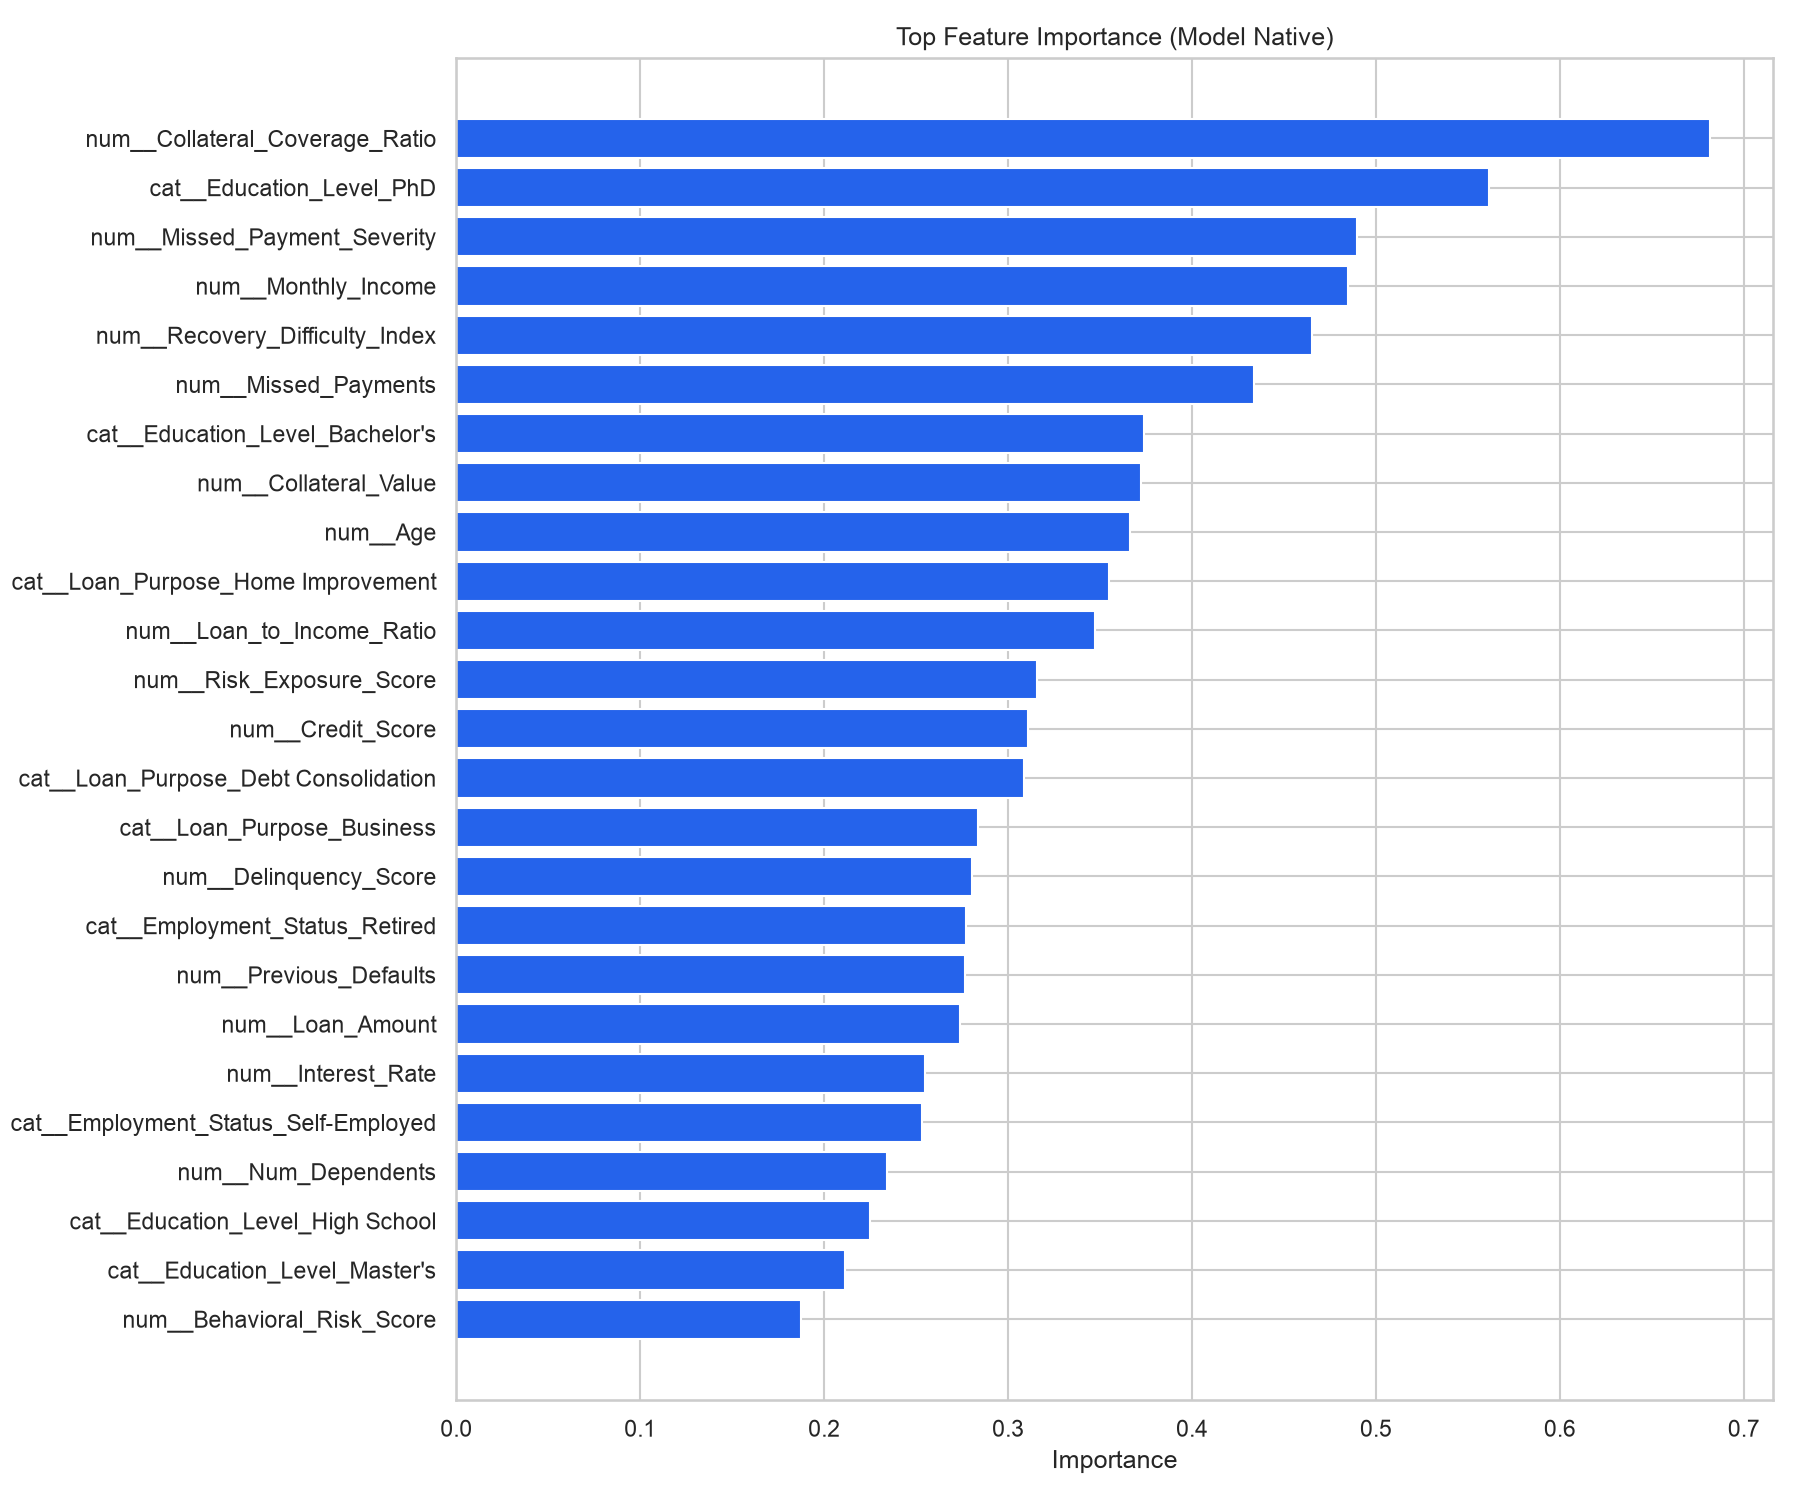

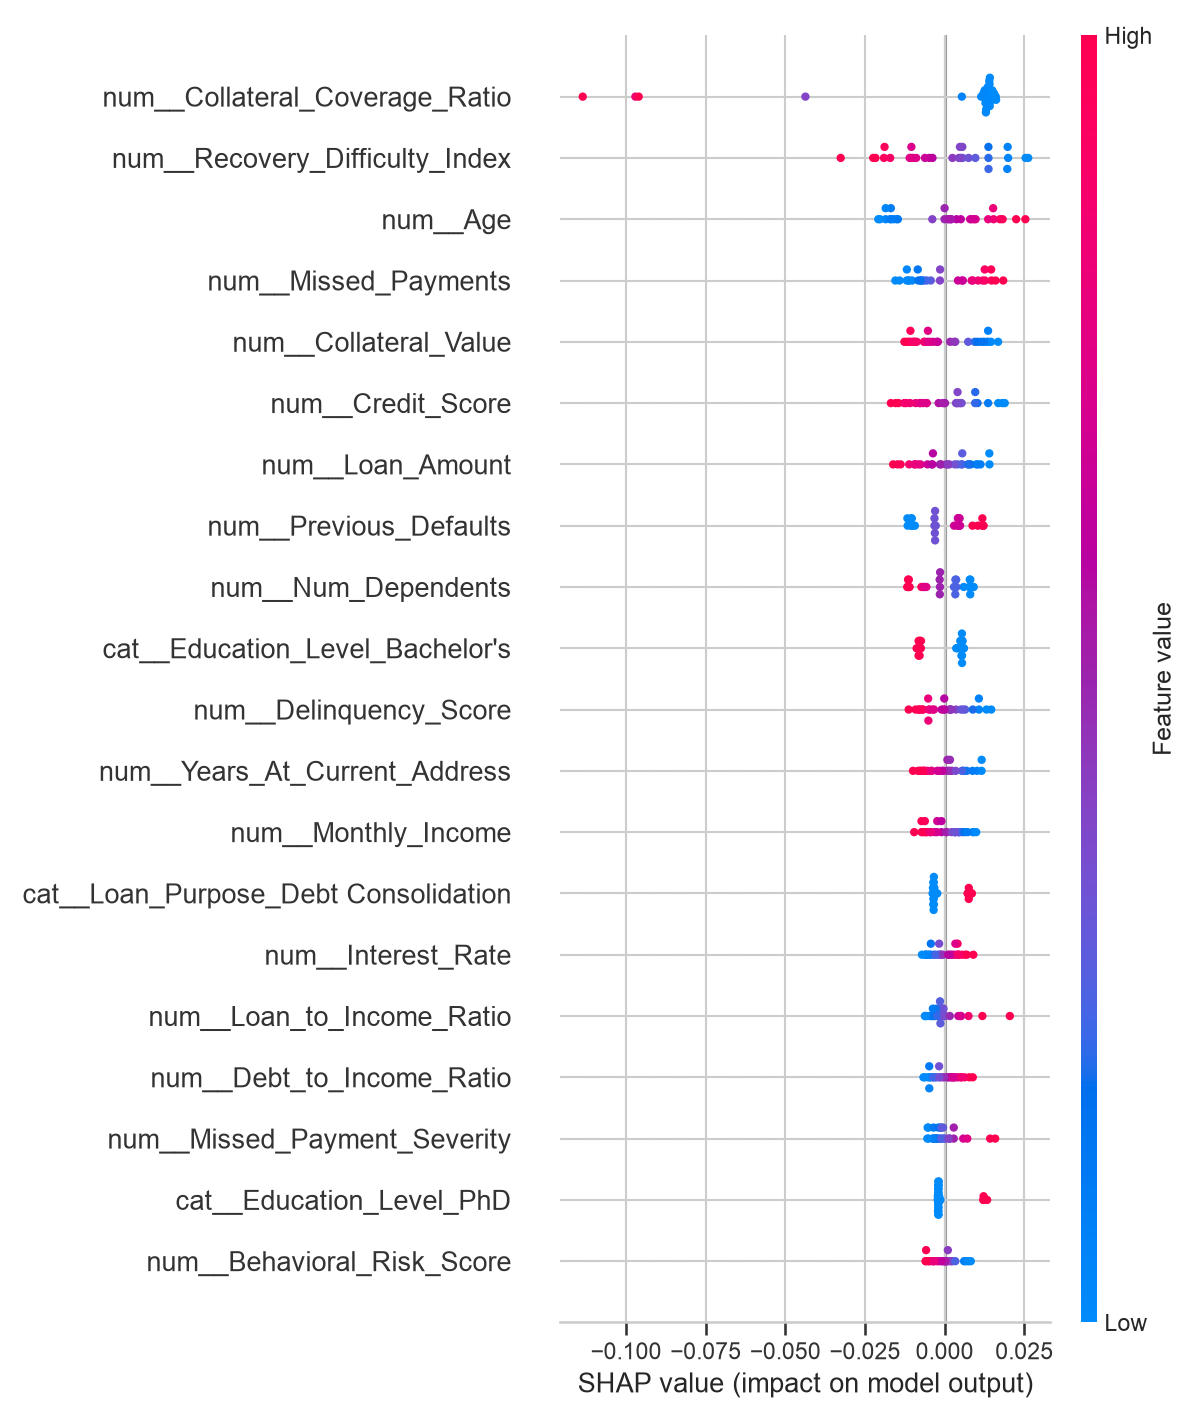

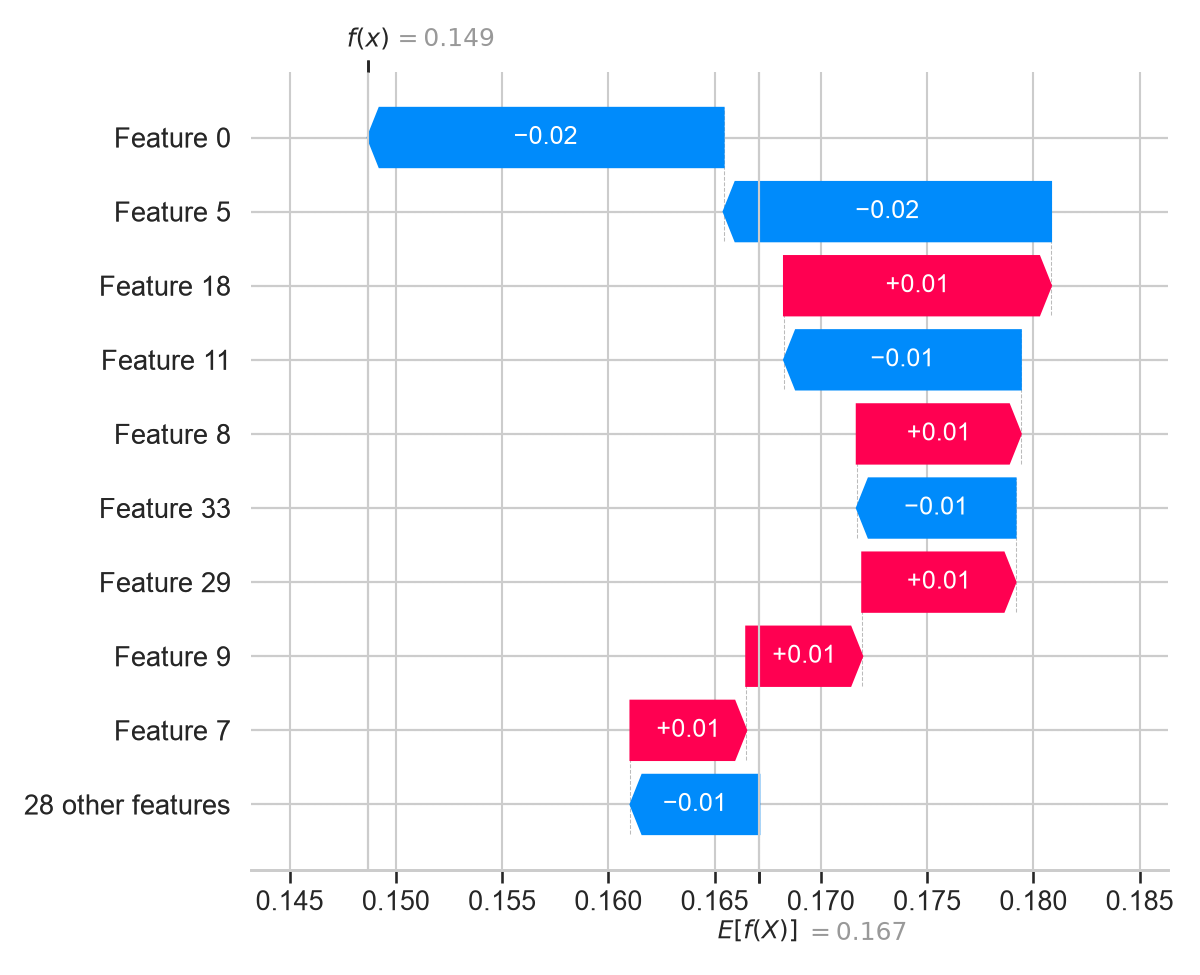

In [5]:
from IPython.display import Image, HTML, display

for image_path in [
    FIGURES_DIR / "feature_importance.png",
    FIGURES_DIR / "shap_summary.png",
    FIGURES_DIR / "shap_waterfall.png",
]:
    if image_path.exists():
        display(Image(filename=str(image_path)))

force_html = FIGURES_DIR / "shap_force.html"
if force_html.exists():
    display(HTML(force_html.read_text()))


## Strategy logic
Risk tiers are not fixed constants. They are learned from portfolio quantiles, then mapped to operational actions.
